In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from collections import Counter

DATA_DIR = '../data'
PRODUCT = 'INTARIAN_PEPPER_ROOT'

In [2]:
# Load all price CSVs
price_files = sorted(glob.glob(f'{DATA_DIR}/prices_round_1_day_*.csv'))
prices = pd.concat(
    [pd.read_csv(f, sep=';') for f in price_files],
    ignore_index=True
)
prices = prices[prices['product'] == PRODUCT].copy()
prices['global_ts'] = prices['day'] * 1_000_000 + prices['timestamp']
prices = prices.sort_values('global_ts').reset_index(drop=True)

# Mid price = (best bid + best ask) / 2, forward fill when either side is missing
prices['best_bid'] = prices['bid_price_1'].ffill()
prices['best_ask'] = prices['ask_price_1'].ffill()
prices['mid_price'] = (prices['best_bid'] + prices['best_ask']) / 2

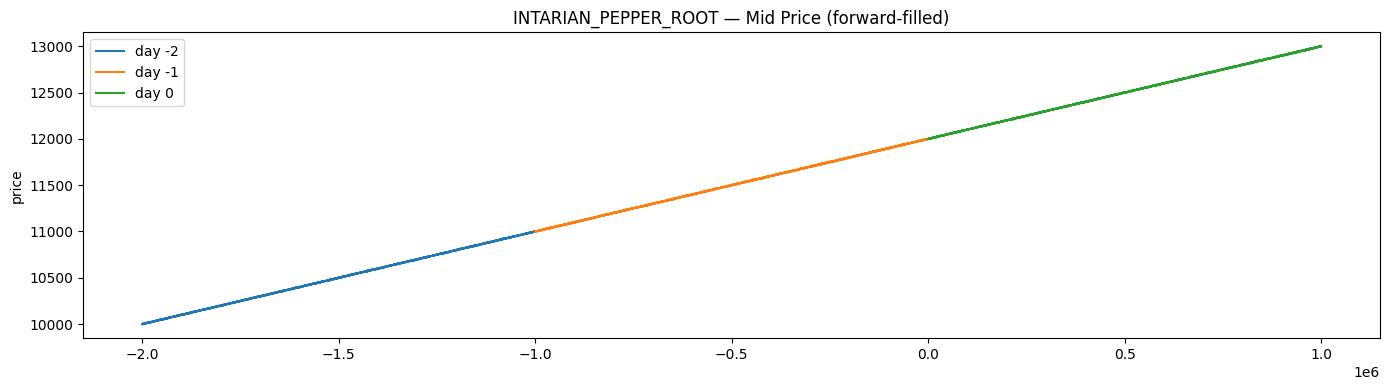

In [3]:
# Plot: mid price over time
fig, ax = plt.subplots(figsize=(14, 4))
for day in sorted(prices['day'].unique()):
    d = prices[prices['day'] == day]
    ax.plot(d['global_ts'], d['mid_price'], label=f'day {day}')
ax.set_title(f'{PRODUCT} — Mid Price (forward-filled)')
ax.set_ylabel('price')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Fit straight line over all mid prices
x = prices['global_ts'].values
y = prices['mid_price'].values

slope, intercept = np.polyfit(x, y, 1)
trend = slope * x + intercept

ss_res = np.sum((y - trend) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f'slope:     {slope:.6e}')
print(f'intercept: {intercept:.4f}')
print(f'R²:        {r2:.6f}')

slope:     1.000004e-03
intercept: 11999.9749
R²:        0.999998


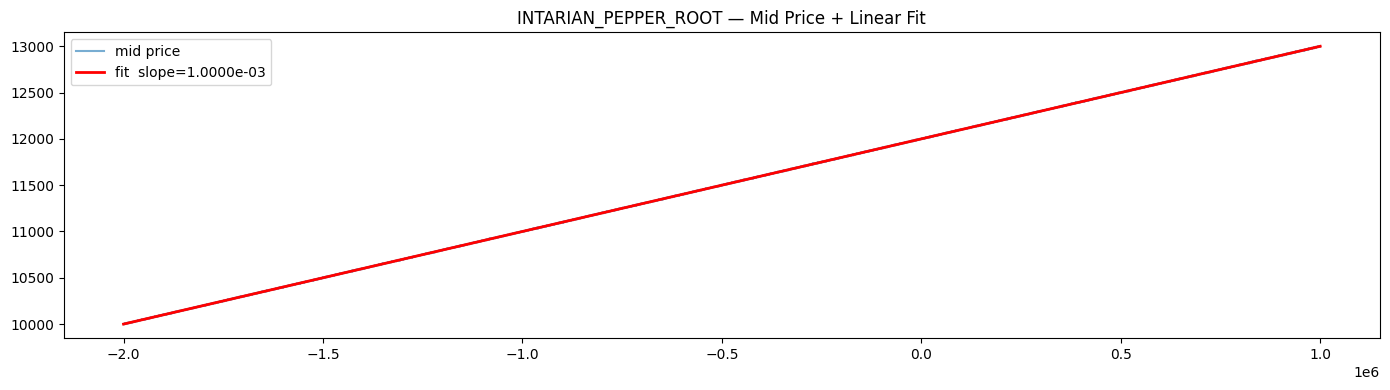

In [5]:
# Plot: mid price + fitted line
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x, y, alpha=0.6, label='mid price')
ax.plot(x, trend, color='red', linewidth=2, label=f'fit  slope={slope:.4e}')
ax.set_title(f'{PRODUCT} — Mid Price + Linear Fit')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Detrend all orders
for i in range(1, 4):
    prices[f'detrended_bid{i}'] = prices[f'bid_price_{i}'] - trend
    prices[f'detrended_ask{i}'] = prices[f'ask_price_{i}'] - trend
prices['detrended_mid'] = prices['mid_price'] - trend

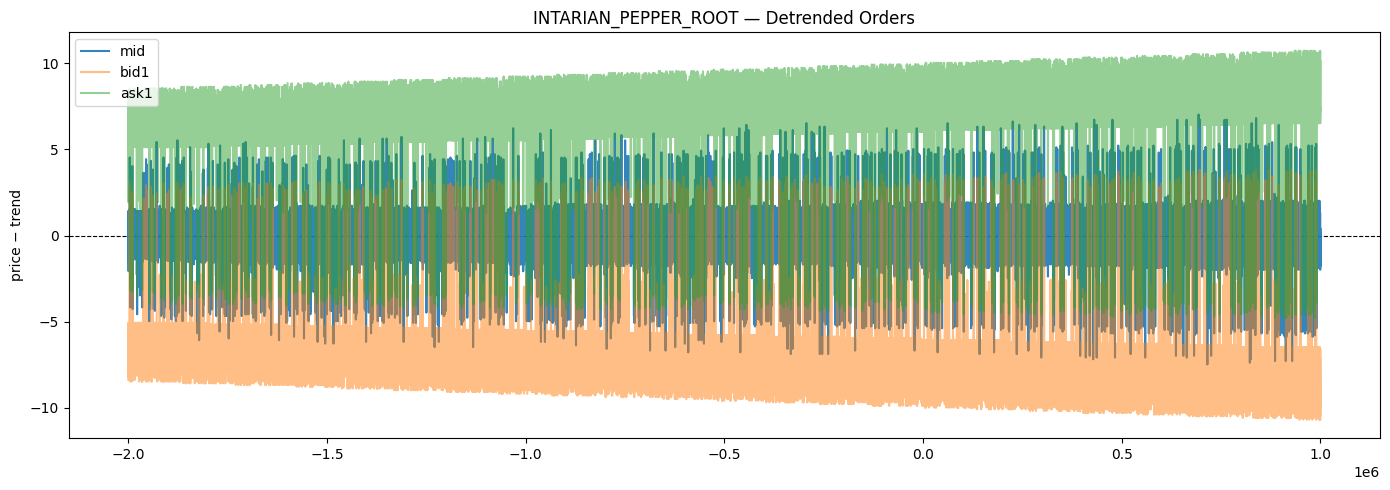

In [7]:
# Plot: detrended mid + level-1 bid/ask
fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.plot(prices['global_ts'], prices['detrended_mid'],  alpha=0.9, label='mid')
ax.plot(prices['global_ts'], prices['detrended_bid1'], alpha=0.5, label='bid1')
ax.plot(prices['global_ts'], prices['detrended_ask1'], alpha=0.5, label='ask1')
ax.set_title(f'{PRODUCT} — Detrended Orders')
ax.set_ylabel('price − trend')
ax.legend()
plt.tight_layout()
plt.show()

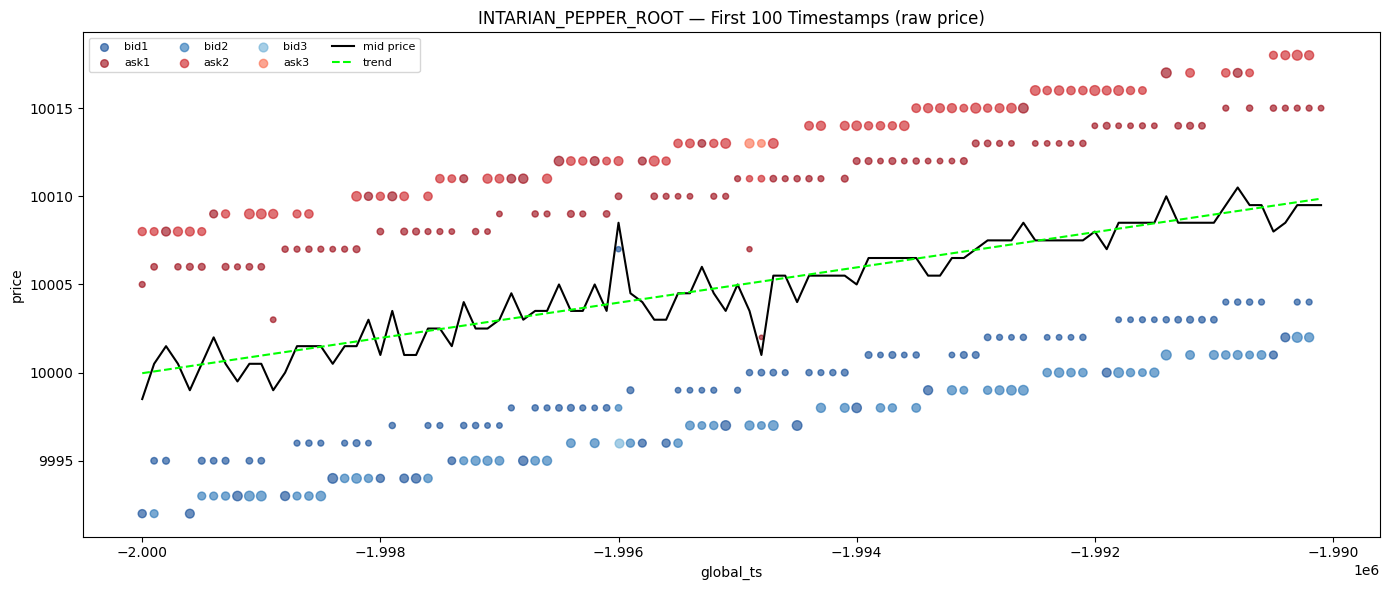

In [8]:
# Zoomed: first 100 timestamps — mid price, trend line, orderbook pixels
sub100 = prices.iloc[:100]
ts100  = sub100['global_ts'].values
trend100 = slope * ts100 + intercept

blues = ['#084594', '#2171b5', '#6baed6']
reds  = ['#99000d', '#cb181d', '#fb6a4a']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (bc, rc) in enumerate(zip(blues, reds), start=1):
    bp = sub100[f'bid_price_{i}'].values
    bv = sub100[f'bid_volume_{i}'].values
    ap = sub100[f'ask_price_{i}'].values
    av = sub100[f'ask_volume_{i}'].values
    valid_b = ~np.isnan(bp) & ~np.isnan(bv)
    valid_a = ~np.isnan(ap) & ~np.isnan(av)
    ax.scatter(ts100[valid_b], bp[valid_b], s=bv[valid_b] * 2, color=bc, alpha=0.6, label=f'bid{i}')
    ax.scatter(ts100[valid_a], ap[valid_a], s=av[valid_a] * 2, color=rc, alpha=0.6, label=f'ask{i}')

ax.plot(ts100, sub100['mid_price'].values, color='black', linewidth=1.5, label='mid price', zorder=5)
ax.plot(ts100, trend100, color='lime', linewidth=1.5, linestyle='--', label='trend', zorder=6)
ax.set_title(f'{PRODUCT} — First 100 Timestamps (raw price)')
ax.set_xlabel('global_ts')
ax.set_ylabel('price')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

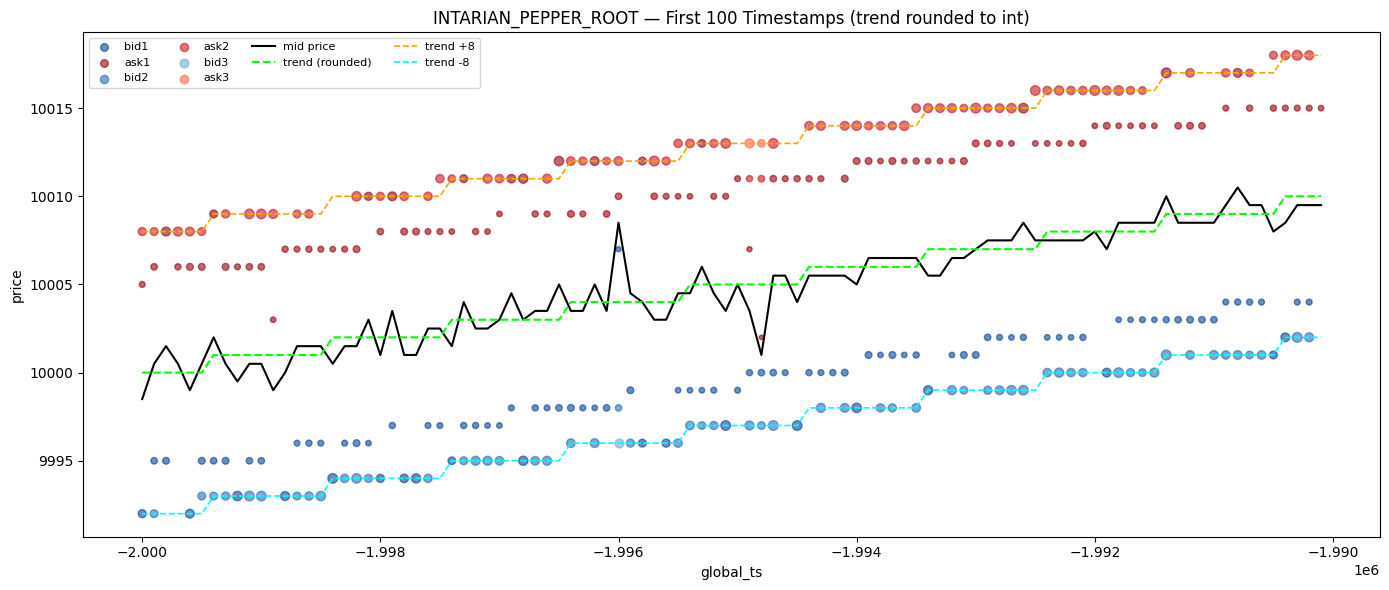

In [9]:
# Same zoomed view with trend rounded to nearest integer + ±8 bands
trend100_rounded = np.round(trend100)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (bc, rc) in enumerate(zip(blues, reds), start=1):
    bp = sub100[f'bid_price_{i}'].values
    bv = sub100[f'bid_volume_{i}'].values
    ap = sub100[f'ask_price_{i}'].values
    av = sub100[f'ask_volume_{i}'].values
    valid_b = ~np.isnan(bp) & ~np.isnan(bv)
    valid_a = ~np.isnan(ap) & ~np.isnan(av)
    ax.scatter(ts100[valid_b], bp[valid_b], s=bv[valid_b] * 2, color=bc, alpha=0.6, label=f'bid{i}')
    ax.scatter(ts100[valid_a], ap[valid_a], s=av[valid_a] * 2, color=rc, alpha=0.6, label=f'ask{i}')

ax.plot(ts100, sub100['mid_price'].values, color='black',  linewidth=1.5, label='mid price', zorder=5)
ax.plot(ts100, trend100_rounded,     color='lime',   linewidth=1.5, linestyle='--', label='trend (rounded)', zorder=6)
ax.plot(ts100, trend100_rounded + 8, color='orange', linewidth=1.2, linestyle='--', label='trend +8', zorder=6)
ax.plot(ts100, trend100_rounded - 8, color='cyan',   linewidth=1.2, linestyle='--', label='trend -8', zorder=6)
ax.set_title(f'{PRODUCT} — First 100 Timestamps (trend rounded to int)')
ax.set_xlabel('global_ts')
ax.set_ylabel('price')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

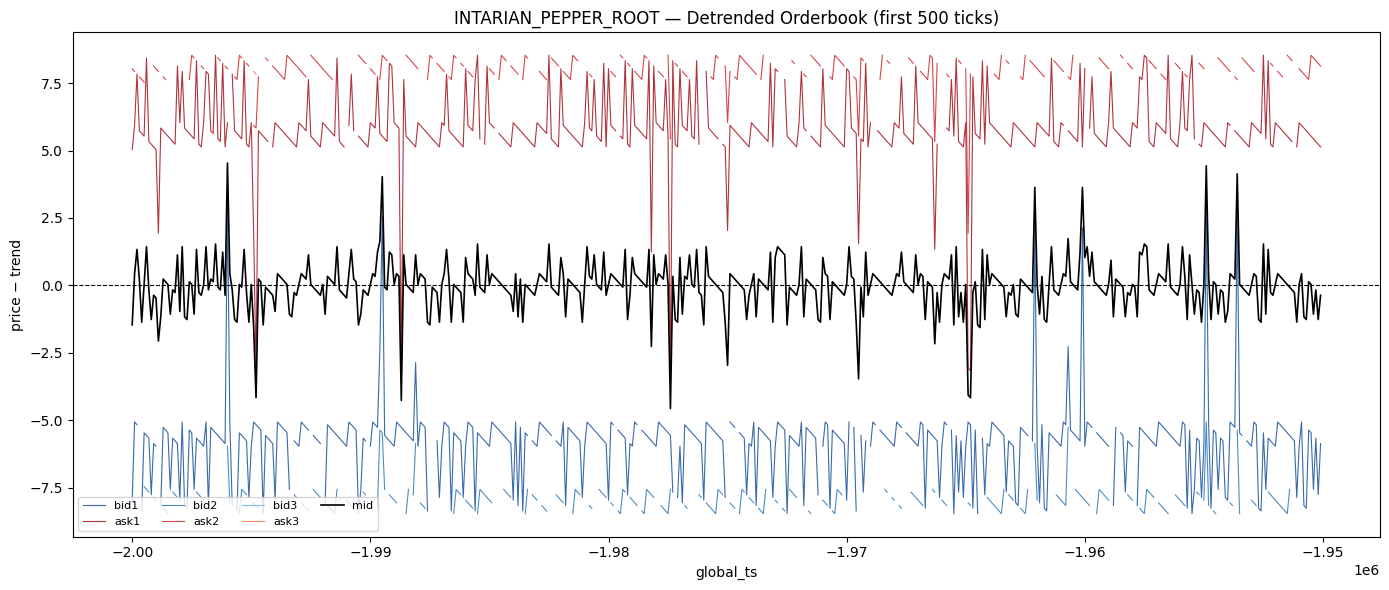

In [10]:
# First 500 ticks of detrended orderbook (all levels)
sub = prices.iloc[:500]
ts  = sub['global_ts']

fig, ax = plt.subplots(figsize=(14, 6))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, (bc, rc) in enumerate(zip(blues, reds), start=1):
    ax.plot(ts, sub[f'detrended_bid{i}'], color=bc, alpha=0.8, linewidth=0.8, label=f'bid{i}')
    ax.plot(ts, sub[f'detrended_ask{i}'], color=rc, alpha=0.8, linewidth=0.8, label=f'ask{i}')
ax.plot(ts, sub['detrended_mid'], color='black', linewidth=1.2, label='mid')
ax.set_title(f'{PRODUCT} — Detrended Orderbook (first 500 ticks)')
ax.set_xlabel('global_ts')
ax.set_ylabel('price − trend')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
# Build bid/ask detrended arrays
bid_deltas, bid_vols = [], []
ask_deltas, ask_vols = [], []

for i in range(1, 4):
    p_col, v_col = f'bid_price_{i}', f'bid_volume_{i}'
    mask = prices[p_col].notna() & prices[v_col].notna()
    bid_deltas.extend((prices.loc[mask, p_col].values - trend[mask.values]).tolist())
    bid_vols.extend(prices.loc[mask, v_col].values.tolist())

    p_col, v_col = f'ask_price_{i}', f'ask_volume_{i}'
    mask = prices[p_col].notna() & prices[v_col].notna()
    ask_deltas.extend((prices.loc[mask, p_col].values - trend[mask.values]).tolist())
    ask_vols.extend(prices.loc[mask, v_col].values.tolist())

# Load trades
trade_files = sorted(glob.glob(f'{DATA_DIR}/trades_round_1_day_*.csv'))
trades_raw = []
for f in trade_files:
    day_val = int(os.path.basename(f).split('day_')[1].replace('.csv', ''))
    df = pd.read_csv(f, sep=';')
    df['day'] = day_val
    trades_raw.append(df)
trades = pd.concat(trades_raw, ignore_index=True)
trades = trades[trades['symbol'] == PRODUCT].copy()
trades['global_ts'] = trades['day'] * 1_000_000 + trades['timestamp']
trades = trades.sort_values('global_ts').reset_index(drop=True)

trade_trend = slope * trades['global_ts'].values + intercept
trades['detrended_price'] = trades['price'] - trade_trend

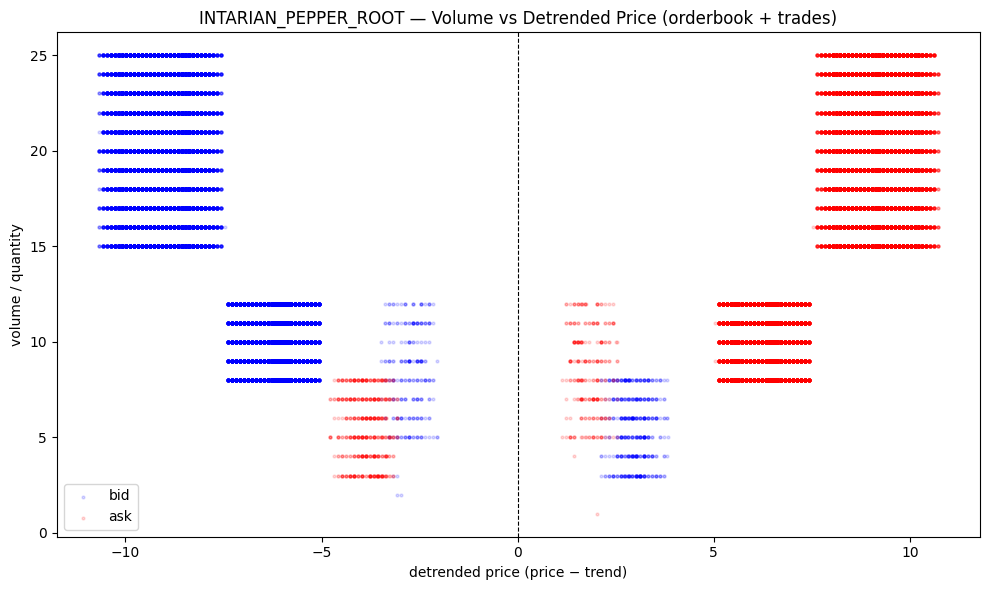

In [12]:
# Scatter: volume vs detrended price (orderbook + trades)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(bid_deltas, bid_vols, color='blue', alpha=0.15, s=4, label='bid')
ax.scatter(ask_deltas, ask_vols, color='red',  alpha=0.15, s=4, label='ask')
# ax.scatter(trades['detrended_price'], trades['quantity'], color='green', alpha=0.4, s=10, label='trades', zorder=5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('detrended price (price − trend)')
ax.set_ylabel('volume / quantity')
ax.set_title(f'{PRODUCT} — Volume vs Detrended Price (orderbook + trades)')
ax.legend()
plt.tight_layout()
plt.show()

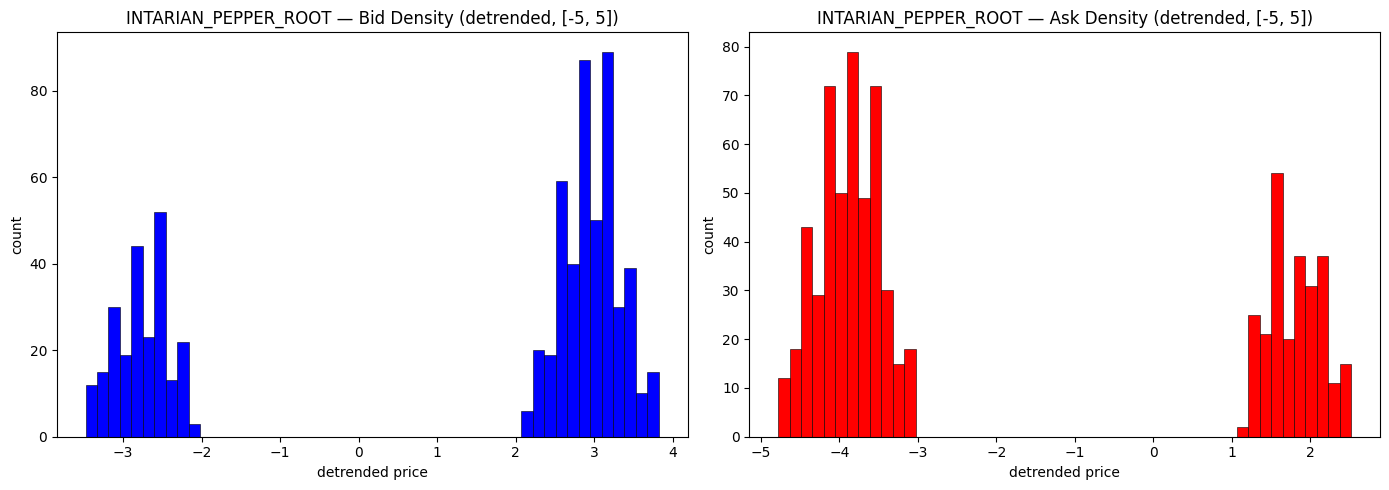

In [13]:
# Count density: detrended orderbook prices in [-5, 5]
bid_arr = np.array(bid_deltas)
ask_arr = np.array(ask_deltas)

bid_filtered = bid_arr[(bid_arr >= -5) & (bid_arr <= 5)]
ask_filtered = ask_arr[(ask_arr >= -5) & (ask_arr <= 5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(bid_filtered, bins=50, color='blue', edgecolor='black', linewidth=0.4)
ax1.set_xlabel('detrended price')
ax1.set_ylabel('count')
ax1.set_title(f'{PRODUCT} — Bid Density (detrended, [-5, 5])')

ax2.hist(ask_filtered, bins=50, color='red', edgecolor='black', linewidth=0.4)
ax2.set_xlabel('detrended price')
ax2.set_ylabel('count')
ax2.set_title(f'{PRODUCT} — Ask Density (detrended, [-5, 5])')
plt.tight_layout()
plt.show()

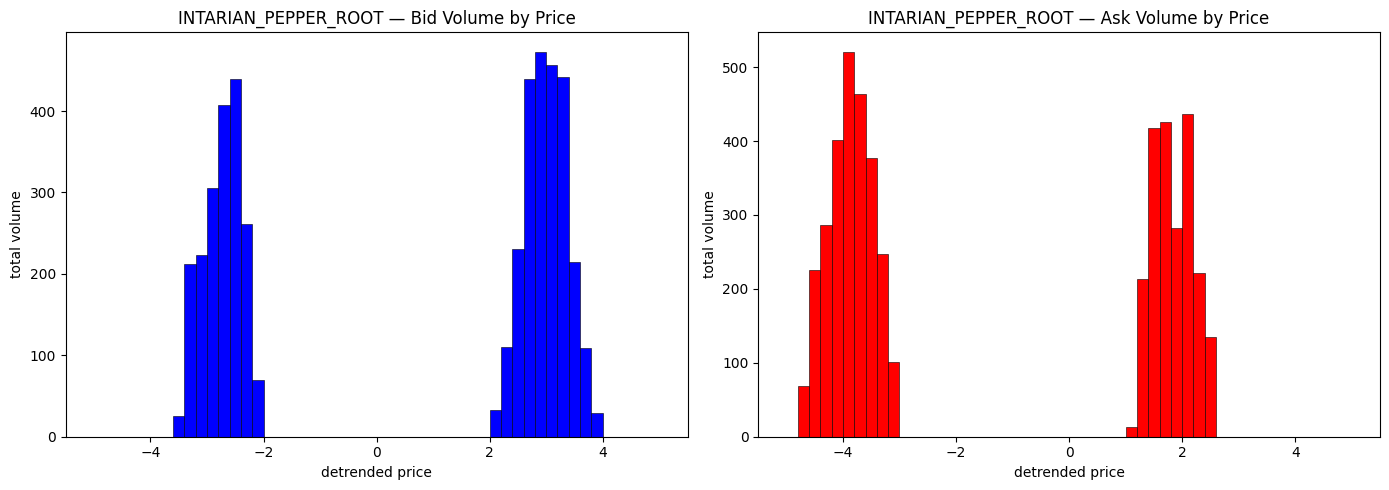

In [14]:
# Volume-weighted histogram: total volume per price bin in [-5, 5]
bid_vol_arr = np.array(bid_vols)
ask_vol_arr = np.array(ask_vols)

bid_mask = (bid_arr >= -5) & (bid_arr <= 5)
ask_mask = (ask_arr >= -5) & (ask_arr <= 5)

bins = np.linspace(-5, 5, 51)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(bid_arr[bid_mask], bins=bins, weights=bid_vol_arr[bid_mask], color='blue', edgecolor='black', linewidth=0.4)
ax1.set_xlabel('detrended price')
ax1.set_ylabel('total volume')
ax1.set_title(f'{PRODUCT} — Bid Volume by Price')

ax2.hist(ask_arr[ask_mask], bins=bins, weights=ask_vol_arr[ask_mask], color='red', edgecolor='black', linewidth=0.4)
ax2.set_xlabel('detrended price')
ax2.set_ylabel('total volume')
ax2.set_title(f'{PRODUCT} — Ask Volume by Price')
plt.tight_layout()
plt.show()

## Outlier PDF Reconstruction

The detrended orderbook reveals that most orders cluster at a small set of fixed integer offsets from the trend — consistent with a generator that produces continuous values on a few straight lines and **rounds to the nearest integer** before placing the order.

For the **outlier** orders (those not on the dominant lines), the same rounding applies. If the true underlying signal is a continuous random variable $X$, and we only observe $y = \text{round}(X)$, then given observation $y$ the maximum-entropy posterior for $X$ is:

$$X \mid y \sim \text{Uniform}\bigl[y - 0.5,\; y + 0.5\bigr]$$

Summing this uniform contribution across all observed outlier values gives a piecewise-flat estimate of the true continuous PDF — equivalent to a rectangular kernel density estimate with bandwidth 1. Orders beyond $|\delta| > 5$ are excluded as they are deterministic fills always placed at fixed offsets.

In [15]:
# Identify dominant line levels (>1% of all observations)
all_detrended = np.concatenate([bid_arr, ask_arr])
rounded_all   = np.round(all_detrended).astype(int)
level_counts  = Counter(rounded_all)
total_obs     = len(rounded_all)
line_levels   = set(v for v, c in level_counts.items() if c / total_obs > 0.01)
print(f'Line levels (detrended): {sorted(line_levels)}')

# Separate outliers and filter to [-5, 5]
bid_outlier_mask = np.array([round(v) not in line_levels for v in bid_arr])
ask_outlier_mask = np.array([round(v) not in line_levels for v in ask_arr])

bid_outliers = bid_arr[bid_outlier_mask & (bid_arr >= -5) & (bid_arr <= 5)]
ask_outliers = ask_arr[ask_outlier_mask & (ask_arr >= -5) & (ask_arr <= 5)]
print(f'Bid outliers: {len(bid_outliers)}  Ask outliers: {len(ask_outliers)}')

Line levels (detrended): [np.int64(-10), np.int64(-9), np.int64(-8), np.int64(-7), np.int64(-6), np.int64(-5), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Bid outliers: 697  Ask outliers: 710


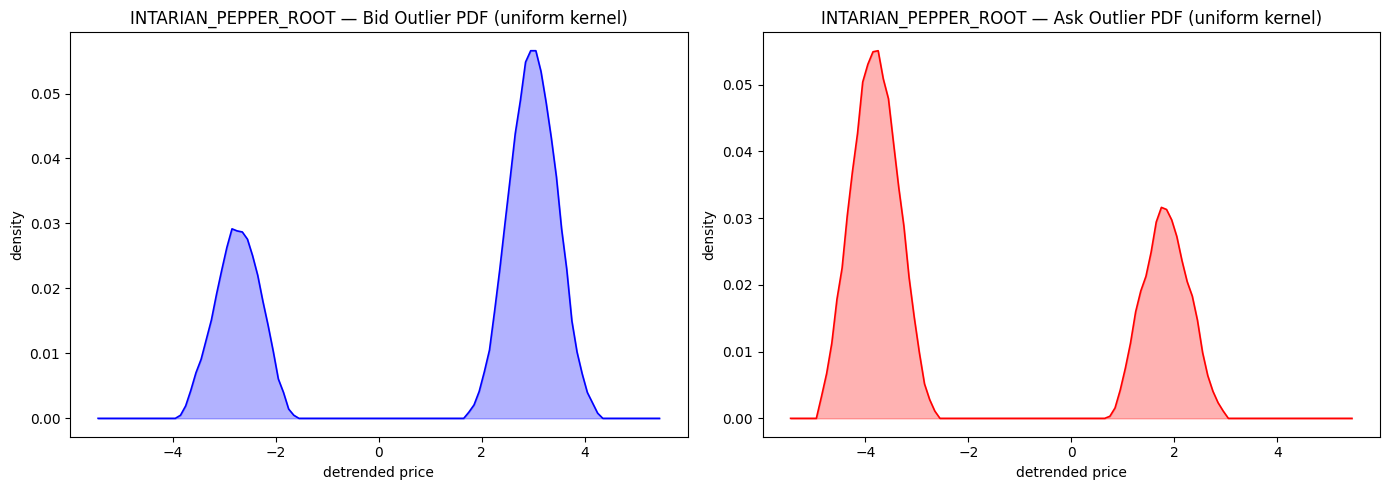

In [16]:
# Uniform kernel PDF
fine_bins   = np.arange(-5.5, 5.6, 0.1)
bin_centers = (fine_bins[:-1] + fine_bins[1:]) / 2

def uniform_kernel_pdf(values, bins):
    density = np.zeros(len(bins) - 1)
    for x in values:
        in_range = (bins[:-1] >= x - 0.5) & (bins[1:] <= x + 0.5)
        if in_range.any():
            density[in_range] += 1.0 / in_range.sum()
    density /= len(values)
    return density

bid_pdf = uniform_kernel_pdf(bid_outliers, fine_bins)
ask_pdf = uniform_kernel_pdf(ask_outliers, fine_bins)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(bin_centers, bid_pdf, color='blue', linewidth=1.2)
ax1.fill_between(bin_centers, bid_pdf, alpha=0.3, color='blue')
ax1.set_xlabel('detrended price')
ax1.set_ylabel('density')
ax1.set_title(f'{PRODUCT} — Bid Outlier PDF (uniform kernel)')

ax2.plot(bin_centers, ask_pdf, color='red', linewidth=1.2)
ax2.fill_between(bin_centers, ask_pdf, alpha=0.3, color='red')
ax2.set_xlabel('detrended price')
ax2.set_ylabel('density')
ax2.set_title(f'{PRODUCT} — Ask Outlier PDF (uniform kernel)')
plt.tight_layout()
plt.show()